# Tutorial
Ganti runtime type dengan klik panah bawah di sebelah tulisan connect dan klik pada change runtime type
Pilih T4 GPU lalu klik save
Lalu tinggal jalankan kode di bawah ini hingga mencapai teks "Testing"

Training model memakan waktu sekitar 2 jam, pastikan agar laptop/komputer yang melakukan training tidak masuk idle/tidak digunakan, tetap awasi dengan gerakan kursor mouse agar tidak dianggap diam oleh google colab sehingga tidak terputus koneksi ketika training model

Ketika training selesai, cek dengan klik pada ikon folder/files di sebelah kiri dibawah ikon kunci, lalu cari runs/detect/{} di dalamnya ada folder weights, di sinilah model tersimpan, bisa didownload untuk last.pt atau best.pt

# Training

In [1]:
!pip install roboflow tensorflow

from roboflow import Roboflow
rf = Roboflow(api_key="oSqbdWgbnJkiVfOWl18o")
project = rf.workspace("valll-rtclj").project("fmd-and-lsd-cattle-disease")
version = project.version(1)
dataset = version.download("folder")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 41.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
loading Roboflow workspace...
loading Roboflow project...
Exporting format folder in progress : 86.0%
Version export complete for folder format



Extracting Dataset Version Zip to FMD-and-LSD-cattle-disease-1 in folder:: 100%|██████████| 1175/1175 [00:00<00:00, 6717.32it/s]


In [2]:
import os
print(f"Direktori saat ini: {os.getcwd()}")


Direktori saat ini: /content


In [3]:
DATA_YAML_PATH = f"{dataset.location}/data.yaml"

print(f"\n--- VERIFIKASI PATH ---")
print(f"Dataset berhasil diunduh ke: {dataset.location}")
print(f"File konfigurasi training: {DATA_YAML_PATH}")

!ls {dataset.location}


--- VERIFIKASI PATH ---
Dataset berhasil diunduh ke: /content/FMD-and-LSD-cattle-disease-1
File konfigurasi training: /content/FMD-and-LSD-cattle-disease-1/data.yaml
README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
DATA_YAML_PATH = "/content/PMK-dan-Penyakit-Lato-Lato-1/data.yaml"

import yaml
import os

DATASET_DIR = os.path.dirname(DATA_YAML_PATH)  # Mengambil direktori dari path data.yaml

# 1. Membaca data.yaml
with open(DATA_YAML_PATH, 'r') as f:
    data = yaml.safe_load(f)

# 2. Tambahkan atau perbarui kunci 'path' ke path absolut dataset
data['path'] = DATASET_DIR

# 3. Menulis ulang file data.yaml
with open(DATA_YAML_PATH, 'w') as f:
    yaml.dump(data, f)

print(f"File {DATA_YAML_PATH} berhasil diperbarui dengan path absolut:")
print(f"path: {DATASET_DIR}")
print("Anda sekarang bisa melanjutkan ke langkah pelatihan.")

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import os
import json

# Menyiapkan Path Dataset
# Pastikan dataset.location mengarah ke hasil download format "Folder Classification"
TRAIN_DIR = f"{dataset.location}/train"
VALID_DIR = f"{dataset.location}/valid"

# Preprocessing Data (Normalisasi nilai piksel dari 0-255 menjadi 0-1)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

print("🔍 Membaca data dari struktur folder...")

# Membaca dataset langsung dari struktur folder
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224), # Ukuran standar MobileNetV2
    batch_size=32,
    class_mode='categorical' # 'categorical' otomatis menangani Single-Label secara one-hot
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

NUM_CLASSES = train_generator.num_classes

if NUM_CLASSES == 0:
    print("❌ ERROR: Tidak ada kelas yang ditemukan! Pastikan format export Roboflow adalah 'Folder Classification'.")
else:
    print(f"✅ Ditemukan {NUM_CLASSES} kelas: {list(train_generator.class_indices.keys())}")

# 1. Memuat model dasar MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Membekukan bobot dasar (Transfer Learning)
base_model.trainable = False

# 2. Menambahkan layer klasifikasi
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
# Menggunakan 'softmax' memastikan model hanya memilih 1 kelas paling dominan
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# Menggabungkan model
model = Model(inputs=base_model.input, outputs=predictions)

# 3. Kompilasi model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', # Loss untuk klasifikasi single-label
              metrics=['accuracy'])

print("\n🚀 Memulai training MobileNetV2 (Folder Structure) selama 50 epoch...")

# 4. Melatih model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=valid_generator
)

# 5. Menyimpan model ke format native Keras (.keras)
MODEL_PATH = '/content/tes1_best.keras'
model.save(MODEL_PATH)
print(f"\n✅ Model berhasil disimpan di {MODEL_PATH}")

# Menyimpan mapping nama kelas ke JSON agar mudah digunakan saat testing
class_indices = {v: k for k, v in train_generator.class_indices.items()}
with open('/content/class_names.json', 'w') as f:
    json.dump(class_indices, f)

🔍 Membaca data dari struktur folder...
Found 1026 images belonging to 3 classes.
Found 98 images belonging to 3 classes.
✅ Ditemukan 3 kelas: ['FMD', 'Healthy', 'LSD']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Memulai training MobileNetV2 (Folder Structure) selama 50 epoch...
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 732ms/step - accuracy: 0.8674 - loss: 0.3640 - val_accuracy: 0.9082 - val_loss: 0.2622
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9815 - loss: 0.0689 - val_accuracy: 0.8980 - val_loss: 0.3043
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9922 - loss: 0.0293 - val_accuracy: 0.9286 - val_loss: 0.2544
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9990 - loss: 0.0159 - val_accuracy: 0.9286 - val_loss: 0.2953
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9990 - loss: 0.0090 - val_accuracy: 0.9286 - val_loss: 0.2801
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 1.0000 - loss

# Testing

In [5]:
# Instal pustaka yang dibutuhkan
!pip install ultralytics opencv-python-headless -q
from ultralytics import YOLO
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

print("Setup Selesai. Lanjutkan ke pemuatan model.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup Selesai. Lanjutkan ke pemuatan model.


In [ ]:
# --- KONFIGURASI PENGGUNA ---
# Ganti dengan path file model OBB Anda
MODEL_PATH = '/content/best.pt'
# MODEL_PATH = '/content/beras best all.pt'

# Ganti dengan path gambar yang akan diuji
GAMBAR_UJI = '/content/koran.jpg'

# Ambang batas kepercayaan (confidence). Turunkan jika deteksi yang terlihat tidak terhitung.
CONF_THRESHOLD = 0.30

# DAFTAR KELAS TARGET (HARUS SAMA PERSIS DENGAN NAMA KELAS DI DATASET ANDA)
TARGET_CLASSES = ['Anorganik', 'Berbahaya', 'Organik']
# -----------------------------


# Pemuatan Model
try:
    model = YOLO(MODEL_PATH)
    print(f"\n✅ Model '{MODEL_PATH}' berhasil dimuat.")
    print("Daftar Kelas Model:", model.names)
except Exception as e:
    print(f"\n❌ ERROR: Gagal memuat model. Pastikan path benar dan file ada.")
    print(e)
    # Hentikan eksekusi jika model gagal dimuat
    # raise


✅ Model '/content/best.pt' berhasil dimuat.
Daftar Kelas Model: {0: 'Anorganik', 1: 'Berbahaya', 2: 'Organik'}



📦 Memulai prediksi pada gambar: /content/sapi2.jpg

✅ Hasil Visual Klasifikasi:


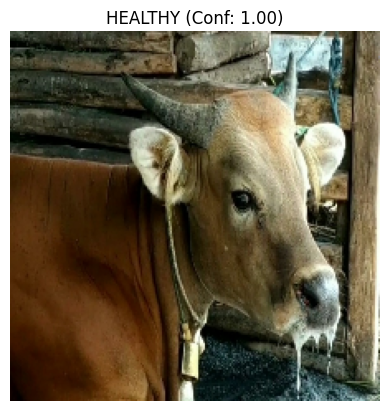


💡 Kesimpulan Prediksi:
    - Terdeteksi sebagai: HEALTHY
    - Tingkat keyakinan: 99.60%

📄 Output JSON:
{
  "predictions": [
    {
      "class": "Healthy",
      "class_id": 1,
      "confidence": 0.9960140585899353
    }
  ]
}


In [15]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import json
import matplotlib.pyplot as plt

def prediksi_mobilenet(image_path, model_path, class_json_path):
    # 1. Memuat model dan file JSON berisi nama kelas
    try:
        model = load_model(model_path)
        with open(class_json_path, 'r') as f:
            # Karena JSON key selalu string (misal: "0", "1"), kita biarkan aslinya
            class_names = json.load(f)
    except Exception as e:
        print("❌ ERROR: Gagal memuat model atau file JSON kelas.")
        print(e)
        return {"predictions": []}

    print(f"\n📦 Memulai prediksi pada gambar: {image_path}")

    # 2. Memuat dan memproses gambar uji (harus disamakan dengan saat training: 224x224 dan rescale 1/255)
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # 3. Melakukan inferensi / tebakan model
    predictions = model.predict(img_array, verbose=0)

    # 4. Mencari kelas dengan probabilitas / confidence tertinggi
    predicted_class_idx = np.argmax(predictions[0])
    confidence = float(predictions[0][predicted_class_idx])

    # Mengambil nama label berdasarkan index (mengubah index ke string untuk mencocokkan key JSON)
    predicted_label = class_names[str(predicted_class_idx)]

    # 5. Menampilkan gambar dan hasil prediksi
    print("\n✅ Hasil Visual Klasifikasi:")
    plt.imshow(img)
    plt.title(f"{predicted_label.upper()} (Conf: {confidence:.2f})")
    plt.axis('off')
    plt.show()

    # 6. Menyusun Output dalam format JSON
    json_output = {
        "predictions": [
            {
                "class": predicted_label,
                "class_id": int(predicted_class_idx),
                "confidence": confidence
            }
        ]
    }

    print(f"\n💡 Kesimpulan Prediksi:")
    print(f"    - Terdeteksi sebagai: {predicted_label.upper()}")
    print(f"    - Tingkat keyakinan: {confidence * 100:.2f}%")

    print("\n📄 Output JSON:")
    print(json.dumps(json_output, indent=2))

    return json_output

# ==========================================
# KONFIGURASI PENGUJIAN (UBAH BAGIAN INI)
# ==========================================
MODEL_PATH = '/content/tes1_best.keras'
CLASS_JSON = '/content/class_names.json'

# Ganti dengan path/nama file gambar yang baru Anda upload ke Colab
GAMBAR_UJI = '/content/sapi2.jpg'

# Jalankan fungsi prediksi
hasil = prediksi_mobilenet(GAMBAR_UJI, MODEL_PATH, CLASS_JSON)

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Reset generator
val_generator.reset()

# Prediksi
y_pred_prob = model.predict(val_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# Label asli
y_true = val_generator.classes

# Nama kelas
class_names = list(val_generator.class_indices.keys())

print("Kelas:", class_names)

NameError: name 'val_generator' is not defined

In [ ]:
!pip install tensorflow

Found 98 images belonging to 3 classes.
⏳ Predicting...
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
Contoh Probabilitas (FMD, LSD, Healthy):
[[    0.93098  3.9337e-07     0.06902]
 [          1  7.2088e-07  7.6546e-09]
 [    0.99992  7.5395e-05   2.605e-08]
 [    0.99996  3.9912e-05  3.5757e-09]
 [          1  4.8589e-09  6.7803e-11]]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


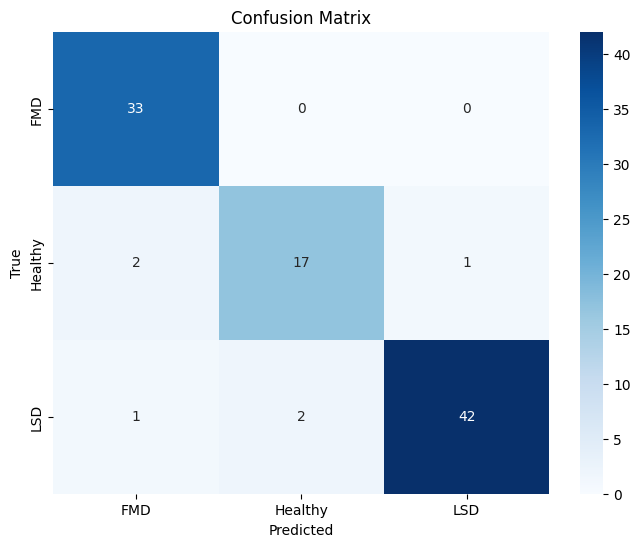


Classification Report:
              precision    recall  f1-score   support

         FMD       0.92      1.00      0.96        33
     Healthy       0.89      0.85      0.87        20
         LSD       0.98      0.93      0.95        45

    accuracy                           0.94        98
   macro avg       0.93      0.93      0.93        98
weighted avg       0.94      0.94      0.94        98



In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Load model
MODEL_PATH = '/content/tes1_best.keras'
model = load_model(MODEL_PATH)

# 2. Definisikan direktori validasi/test
VALID_DIR = '/content/FMD-and-LSD-cattle-disease-1/valid'  # <-- sesuaikan

# 3. BUAT ulang generator (WAJIB, walau sudah training sebelumnya)
valid_datagen = ImageDataGenerator(rescale=1./255)

valid_generator_cm = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 4. Ambil label asli
y_true = valid_generator_cm.classes
nama_kelas = list(valid_generator_cm.class_indices.keys())

# 5. Prediksi
# Tambahkan ini di poin 5 kode Anda
print("⏳ Predicting...")
y_pred_probs = model.predict(valid_generator_cm)

# Lihat 5 prediksi pertama
print("Contoh Probabilitas (FMD, LSD, Healthy):")
print(y_pred_probs[:5])

y_pred = np.argmax(y_pred_probs, axis=1)

y_pred_probs = model.predict(valid_generator_cm)
y_pred = np.argmax(y_pred_probs, axis=1)

# 6. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nama_kelas,
            yticklabels=nama_kelas)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 7. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=nama_kelas))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# 1. Pastikan model yang terbaik sudah dimuat
MODEL_PATH = '/content/mobilenetv2_best.keras'
model = load_model(MODEL_PATH)

# 2. Siapkan ulang Generator Validasi
# PENTING: Untuk Confusion Matrix, shuffle HARUS False agar urutan gambar
# dan tebakannya tidak acak/tertukar
valid_generator_cm = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 3. Dapatkan label asli (kunci jawaban)
y_true = valid_generator_cm.classes
nama_kelas = list(valid_generator_cm.class_indices.keys())

# 4. Lakukan Prediksi ke seluruh data validasi
print("\n⏳ Sedang memprediksi seluruh data validasi untuk Confusion Matrix...")
prediksi_mentah = model.predict(valid_generator_cm, verbose=1)

# 5. Dapatkan label tebakan model (ambil nilai probabilitas tertinggi)
y_pred = np.argmax(prediksi_mentah, axis=1)

# 6. Hitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 7. Visualisasi dengan Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nama_kelas,
            yticklabels=nama_kelas)
plt.title('Confusion Matrix - MobileNetV2', pad=20, fontsize=14)
plt.ylabel('Label Asli (True Label)', fontsize=12)
plt.xlabel('Tebakan Model (Predicted Label)', fontsize=12)
plt.show()

# 8. Tampilkan Laporan Klasifikasi Lengkap
print("\n📊 Laporan Klasifikasi (Classification Report):")
print(classification_report(y_true, y_pred, target_names=nama_kelas))

NameError: name 'valid_datagen' is not defined

In [ ]:
print(model.names)

In [ ]:
print(model.task)

detect


**Reformat/Convert to Tflite**

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("mobilenetv2_best.keras")

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Default = float32
tflite_model_fp32 = converter.convert()

with open("model_fp32.tflite", "wb") as f:
    f.write(tflite_model_fp32)

print("Sukses membuat model_fp32.tflite")

Saved artifact at '/tmp/tmpioluep9h'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139907078119184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078121488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078121680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078119760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078122256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078122448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078119568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078119376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078121296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078121104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078118224

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimasi
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Float16 quantization
converter.target_spec.supported_types = [tf.float16]

tflite_model_fp16 = converter.convert()

with open("model_fp16.tflite", "wb") as f:
    f.write(tflite_model_fp16)

print("Sukses membuat model_fp16.tflite")

Saved artifact at '/tmp/tmpb6mzgo7m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139907078119184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078121488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078121680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078119760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078122256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078122448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078119568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078119376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078121296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078121104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139907078118224

In [ ]:
from ultralytics import YOLO

model = YOLO("beras best all.pt")
model.export(format="tflite")


ModuleNotFoundError: No module named 'ultralytics'

Cek Input/Output Shape Model

In [ ]:
# Install TFLite tools (jika belum)
!pip install tensorflow

In [ ]:
# Cek model info
import tensorflow as tf;
interpreter = tf.lite.Interpreter(model_path='/content/model.tflite');
interpreter.allocate_tensors();
print('Input:', interpreter.get_input_details());
print('Output:', interpreter.get_output_details())

Input: [{'name': 'images', 'index': 0, 'shape': array([  1, 640, 640,   3], dtype=int32), 'shape_signature': array([  1, 640, 640,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output: [{'name': 'Identity', 'index': 611, 'shape': array([   1,    8, 8400], dtype=int32), 'shape_signature': array([   1,    8, 8400], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
